# PLANE PRICES DATA ANALYSIS

## Business Context

The aircraft market includes a wide range of models, from small piston aircraft to high-performance jet aircraft, each with significantly different characteristics and pricing structures.

Understanding what drives aircraft pricing is critical for manufacturers, buyers, and investors, as it allows better valuation, comparison, and decision-making.

Aircraft price is influenced by multiple factors, including size, engine power, performance, and operational capabilities. However, these relationships are not always linear and may vary across different aircraft categories.

## Objective

The objective of this analysis is to identify the key factors that influence aircraft pricing and understand how structural and performance characteristics impact value.

Additionally, the project aims to explore whether aircraft pricing follows consistent patterns across the dataset or if distinct segments exist.

Finally, a predictive model will be developed to estimate aircraft prices based on these characteristics.

## Key Questions
What are the main factors that determine aircraft price?
How do size and engine performance influence pricing?
Are there distinct segments within the dataset (e.g., piston vs jet aircraft)?
Is aircraft pricing driven more by size or by performance efficiency?
Can we build a reliable model to predict aircraft price?

## Initial Hypothesis
Larger aircraft are expected to have higher prices due to increased capacity and structural complexity.
Aircraft with higher engine power and better performance metrics are likely to be more expensive.
Jet and propjet aircraft will form a higher price segment compared to piston aircraft.
Performance efficiency (power relative to size) may be a stronger predictor of price than size alone.


## Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Data Loading

In [2]:
df=pd.read_csv("Plane Price.csv")
df.shape

(517, 16)

## Initial Exploration

In [3]:
df.info()
df.head()
df.describe()
df.describe(include="object")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Model Name               517 non-null    object 
 1   Engine Type              517 non-null    object 
 2   HP or lbs thr ea engine  517 non-null    object 
 3   Max speed Knots          497 non-null    object 
 4   Rcmnd cruise Knots       507 non-null    float64
 5   Stall Knots dirty        502 non-null    float64
 6   Fuel gal/lbs             517 non-null    int64  
 7   All eng rate of climb    513 non-null    object 
 8   Eng out rate of climb    491 non-null    float64
 9   Takeoff over 50ft        492 non-null    float64
 10  Landing over 50ft        517 non-null    object 
 11  Empty weight lbs         516 non-null    object 
 12  Length ft/in             517 non-null    object 
 13  Wing span ft/in          517 non-null    object 
 14  Range N.M.               4

,Model Name,Engine Type,HP or lbs thr ea engine,Max speed Knots,All eng rate of climb,Landing over 50ft,Empty weight lbs,Length ft/in,Wing span ft/in,Range N.M.
count,517,517,517,497,513,517,516,517,517,499
unique,284,4,117,209,264,213,428,183,136,299
top,100 Darter (S.L. Industries),Piston,285,148,"1,250","3,600","1,525",25/1,35/10,550
freq,234,384,37,10,13,16,5,17,34,9


In [4]:
df

,Model Name,Engine Type,HP or lbs thr ea engine,Max speed Knots,Rcmnd cruise Knots,Stall Knots dirty,Fuel gal/lbs,All eng rate of climb,Eng out rate of climb,Takeoff over 50ft,Landing over 50ft,Empty weight lbs,Length ft/in,Wing span ft/in,Range N.M.,Price
0,100 Darter (S.L. Industries),Piston,145,104,91.0,46.0,36,450,900.0,1300.0,"2,050","1,180",25/3,37/5,370,1300000.0
1,7 CCM Champ,Piston,85,89,83.0,44.0,15,600,720.0,800.0,"1,350",820,20/7,36/1,190,1230000.0
2,100 Darter (S.L. Industries),Piston,90,90,78.0,37.0,19,650,475.0,850.0,"1,300",810,21/5,35/0,210,1600000.0
3,7 AC Champ,Piston,85,88,78.0,37.0,19,620,500.0,850.0,"1,300",800,21/5,35/0,210,1300000.0
4,100 Darter (S.L. Industries),Piston,65,83,74.0,33.0,14,370,632.0,885.0,"1,220",740,21/5,35/0,175,1250000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
512,500 A,Propjet,1000,351,334.0,NaN,3819,"3,242",1930.0,2280.0,"12,050","7,856",43/5,47/8,"1,879",4100000.0
513,100 Darter (S.L. Industries),Propjet,720,312,288.0,89.0,578,"2,380",2280.0,3043.0,"11,200","6,837",43/5,47/8,"1,722",3584000.0
514,520,Propjet,720,290,275.0,87.0,390,"2,236",3230.0,3017.0,"11,200","6,389",43/5,47/8,"1,515",3200000.0
515,2180,Propjet,620,275,270.0,77.0,382,"1,750",2940.0,2446.0,"9,474","5,164",36/8,42/8,"1,336",3240000.0


## changes
- 2   HP or lbs thr ea engine  517 non-null    object 
- 3   Max speed Knots          497 non-null    object
- 7   All eng rate of climb    513 non-null    object 
- 10  Landing over 50ft        517 non-null    object 
- 11  Empty weight lbs         516 non-null    object 
- 14  Range N.M.               499 non-null    object
- 12  Length ft/in             517 non-null    object 
- 13  Wing span ft/in          517 non-null    object 
- 14  Range N.M.               499 non-null    object 

## Column Name Cleaning

In [5]:
df.columns=(df.columns.str.strip().str.upper().str.replace(" ","_").str.replace(".",""))

## Missing Values Analysis

In [6]:
missing = df.isna().mean().sort_values(ascending=False) * 100
missing[missing>0]

ENG_OUT_RATE_OF_CLIMB    5.029014
TAKEOFF_OVER_50FT        4.835590
MAX_SPEED_KNOTS          3.868472
RANGE_NM                 3.481625
STALL_KNOTS_DIRTY        2.901354
PRICE                    1.934236
RCMND_CRUISE_KNOTS       1.934236
ALL_ENG_RATE_OF_CLIMB    0.773694
EMPTY_WEIGHT_LBS         0.193424
dtype: float64

## Duplicate Analysis

In [7]:
df.duplicated().sum()

np.int64(0)

## Data Cleaning

In [8]:
cols = [
    "HP_OR_LBS_THR_EA_ENGINE",
    "MAX_SPEED_KNOTS",
    "ALL_ENG_RATE_OF_CLIMB",
    "LANDING_OVER_50FT",
    "EMPTY_WEIGHT_LBS",
    "RANGE_NM"
]
str_cols=["MODEL_NAME","ENGINE_TYPE"]

df_cast=df.copy()
df_cast[cols]=(
    df_cast[cols].astype(str)
    .apply(lambda x: x.str.replace(",","").str.strip())
    .apply(pd.to_numeric,errors="coerce")
)

df_cast[str_cols]=df_cast[str_cols].astype(str).apply(lambda x: x.str.upper().str.strip())

In [9]:
def ft_in_to_float(x):
    try:
        ft, inch = x.split("/")
        return float(ft) + float(inch)/12
    except:
        return np.nan

df_cast["LENGTH_FT"] = df_cast["LENGTH_FT/IN"].apply(ft_in_to_float)
df_cast["WING_SPAN_FT"] = df_cast["WING_SPAN_FT/IN"].apply(ft_in_to_float)
df_cast = df_cast.drop(["LENGTH_FT/IN", "WING_SPAN_FT/IN"], axis=1)

In [10]:
df_cast.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   MODEL_NAME               517 non-null    object 
 1   ENGINE_TYPE              517 non-null    object 
 2   HP_OR_LBS_THR_EA_ENGINE  515 non-null    float64
 3   MAX_SPEED_KNOTS          488 non-null    float64
 4   RCMND_CRUISE_KNOTS       507 non-null    float64
 5   STALL_KNOTS_DIRTY        502 non-null    float64
 6   FUEL_GAL/LBS             517 non-null    int64  
 7   ALL_ENG_RATE_OF_CLIMB    510 non-null    float64
 8   ENG_OUT_RATE_OF_CLIMB    491 non-null    float64
 9   TAKEOFF_OVER_50FT        492 non-null    float64
 10  LANDING_OVER_50FT        516 non-null    float64
 11  EMPTY_WEIGHT_LBS         516 non-null    float64
 12  RANGE_NM                 499 non-null    float64
 13  PRICE                    507 non-null    float64
 14  LENGTH_FT                5

In [11]:
cols = df_cast.select_dtypes(include="number").columns
df_cast[cols] = df_cast[cols].fillna(df_cast[cols].median())
df_cast.isna().sum().sort_values(ascending=False)

MODEL_NAME                 0
ENGINE_TYPE                0
HP_OR_LBS_THR_EA_ENGINE    0
MAX_SPEED_KNOTS            0
RCMND_CRUISE_KNOTS         0
STALL_KNOTS_DIRTY          0
FUEL_GAL/LBS               0
ALL_ENG_RATE_OF_CLIMB      0
ENG_OUT_RATE_OF_CLIMB      0
TAKEOFF_OVER_50FT          0
LANDING_OVER_50FT          0
EMPTY_WEIGHT_LBS           0
RANGE_NM                   0
PRICE                      0
LENGTH_FT                  0
WING_SPAN_FT               0
dtype: int64

Data Cleaning

Several columns contained numerical values stored as text, including commas and inconsistent formatting. These columns were converted to numeric format to enable proper analysis.

Additionally, categorical variables such as model name and engine type were standardized to uppercase and stripped of extra spaces to ensure consistency.

Aircraft dimensions originally stored as "ft/in" strings were transformed into numeric values in feet. This allows these variables to be used in quantitative analysis and modeling.

Missing values were handled using median imputation for numerical columns, ensuring robustness against outliers and preserving the overall distribution of the data.

In [12]:
df_cast.describe()

,HP_OR_LBS_THR_EA_ENGINE,MAX_SPEED_KNOTS,RCMND_CRUISE_KNOTS,STALL_KNOTS_DIRTY,FUEL_GAL/LBS,ALL_ENG_RATE_OF_CLIMB,ENG_OUT_RATE_OF_CLIMB,TAKEOFF_OVER_50FT,LANDING_OVER_50FT,EMPTY_WEIGHT_LBS,RANGE_NM,PRICE,LENGTH_FT,WING_SPAN_FT
count,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,5.170000e+02,517.000000,517.000000
mean,866.678917,211.985493,200.177950,60.656673,1419.379110,1659.437137,2047.065764,1732.750484,7485.489362,4377.405803,911.448743,2.355658e+06,32.270632,39.377982
std,1783.959767,108.092249,103.358089,16.432874,4278.320773,1258.493383,1123.433947,713.646967,10289.442474,5649.738675,696.429643,1.010050e+06,11.703395,8.545025
min,60.000000,78.000000,70.000000,27.000000,12.000000,360.000000,457.000000,500.000000,567.000000,2.300000,117.000000,6.500000e+05,17.583333,16.000000
25%,200.000000,145.000000,131.000000,50.000000,50.000000,924.000000,1365.000000,1265.000000,2650.000000,1575.000000,517.000000,1.600000e+06,25.166667,35.000000
50%,285.000000,177.500000,169.000000,56.000000,89.000000,1200.000000,1706.000000,1525.000000,3625.000000,2286.500000,713.000000,2.000000e+06,28.083333,36.500000
75%,550.000000,236.000000,229.000000,73.000000,335.000000,1820.000000,2280.000000,2110.000000,8800.000000,5164.000000,1100.000000,2.940000e+06,35.500000,42.250000
max,14750.000000,530.000000,511.000000,115.000000,41000.000000,7220.000000,6400.000000,4850.000000,89400.000000,46800.000000,6500.000000,5.100000e+06,96.416667,93.500000


In [13]:
Q1 = df_cast["FUEL_GAL/LBS"].quantile(0.25)
Q3 = df_cast["FUEL_GAL/LBS"].quantile(0.75)

IQR = Q3 - Q1

upper = Q3 + 1.5 * IQR

outliers = df_cast[df_cast["FUEL_GAL/LBS"] > upper]
outliers

,MODEL_NAME,ENGINE_TYPE,HP_OR_LBS_THR_EA_ENGINE,MAX_SPEED_KNOTS,RCMND_CRUISE_KNOTS,STALL_KNOTS_DIRTY,FUEL_GAL/LBS,ALL_ENG_RATE_OF_CLIMB,ENG_OUT_RATE_OF_CLIMB,TAKEOFF_OVER_50FT,LANDING_OVER_50FT,EMPTY_WEIGHT_LBS,RANGE_NM,PRICE,LENGTH_FT,WING_SPAN_FT
49,58 P BARON-PRESS.('77 HGT=9/6) (RANGE BASED ON...,PROPJET,850.0,310.0,259.0,80.0,3645,2437.0,1706.0,1525.0,12590.0,8830.0,1720.0,3500000.0,43.833333,57.916667
152,402C BUSINESS LINER II,JET,3700.0,455.0,417.0,56.0,6707,4059.0,5600.0,3300.0,21500.0,12135.0,1715.0,5100000.0,55.083333,43.750000
153,"402,-A TURBOCHARGED",JET,3700.0,457.0,169.0,56.0,6707,4380.0,4540.0,3109.0,19500.0,12130.0,1715.0,5100000.0,55.083333,43.750000
154,100 DARTER (S.L. INDUSTRIES),JET,8650.0,480.0,442.0,56.0,16665,4200.0,5400.0,3300.0,43250.0,19950.0,3391.0,4100000.0,68.416667,61.833333
155,100 DARTER (S.L. INDUSTRIES),JET,7500.0,480.0,442.0,56.0,14890,3400.0,5700.0,3300.0,41400.0,18660.0,2991.0,4100000.0,68.416667,61.833333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
449,"PA-25 235 C,D PAWNEE (NORMAL CATEGORY)",JET,3300.0,496.0,435.0,106.0,2660,4050.0,1706.0,3440.0,41900.0,20999.0,713.0,4300000.0,60.416667,54.416667
468,100 DARTER (S.L. INDUSTRIES),JET,2900.0,456.0,438.0,56.0,4260,3180.0,3950.0,2930.0,15780.0,9925.0,1530.0,4100000.0,48.416667,43.500000
469,"200 D MEYERS (PROP JETS, INC.)",JET,2500.0,430.0,400.0,77.0,4260,3050.0,3850.0,2800.0,14630.0,9410.0,1513.0,4100000.0,48.416667,43.500000
510,560,PROPJET,850.0,400.0,169.0,90.0,2630,3000.0,2630.0,2650.0,10810.0,7200.0,1746.0,4100000.0,47.250000,46.000000


A significant number of detected outliers (~15% of the dataset) are not errors but represent structurally different aircraft categories.

Specifically, high fuel capacity and engine power correspond to jet aircraft, which operate in a distinct performance and pricing segment compared to smaller piston aircraft.

Therefore, these observations should not be treated as outliers but as a separate segment within the dataset.

## Feature Engineering

In [14]:
df_cast["AIRCRAFT_SIZE"]= df_cast["LENGTH_FT"]*df_cast["WING_SPAN_FT"]
df_cast["POWER_TO_SIZE"] = df_cast["HP_OR_LBS_THR_EA_ENGINE"] / df_cast["AIRCRAFT_SIZE"]
df_cast["WEIGHT_TO_SIZE"] = df_cast["EMPTY_WEIGHT_LBS"] / df_cast["AIRCRAFT_SIZE"]

Feature Engineering

New features were created to better capture the physical and performance characteristics of the aircraft.

- Aircraft Size: calculated as length multiplied by wingspan, serving as a proxy for overall aircraft size.
- Power to Size Ratio: represents how much engine power is available relative to aircraft size.
- Weight to Size Ratio: measures structural density and potential efficiency.

These features aim to capture relationships that are not directly observable from raw variables, improving interpretability and potential predictive performance.

Additionally, the presence of high-value outliers corresponds to jet aircraft, which operate in a different performance and pricing segment compared to piston aircraft.

This indicates that the dataset contains multiple aircraft categories with distinct characteristics, which should be considered in further analysis.

In [15]:
df_cast[["PRICE","AIRCRAFT_SIZE","POWER_TO_SIZE"]].corr()

,PRICE,AIRCRAFT_SIZE,POWER_TO_SIZE
PRICE,1.000000,0.681919,0.791476
AIRCRAFT_SIZE,0.681919,1.000000,0.644264
POWER_TO_SIZE,0.791476,0.644264,1.000000


Key Insights

The analysis shows a strong relationship between aircraft characteristics and price.

- Aircraft size has a strong positive correlation with price (0.68), indicating that larger aircraft tend to be more expensive.
- Power-to-size ratio has an even stronger correlation with price (0.79), suggesting that performance efficiency is a key driver of aircraft value.
- This indicates that not only size but also how efficiently power is utilized plays a critical role in determining aircraft pricing.

These findings suggest that aircraft pricing is influenced by both structural dimensions and performance capabilities.

## Exploratory Data Analysis

## Distribution

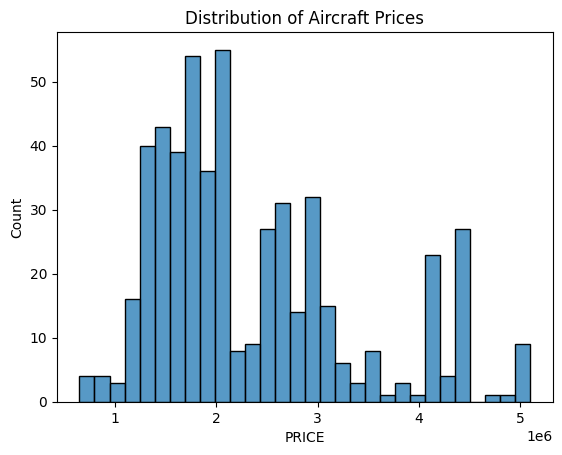

In [16]:
sns.histplot(df_cast["PRICE"], bins=30)
plt.title("Distribution of Aircraft Prices")
plt.show()

Aircraft prices show a right-skewed distribution, with most aircraft concentrated in lower price ranges and a smaller number of high-value aircraft.

## Price by Kind of Engine

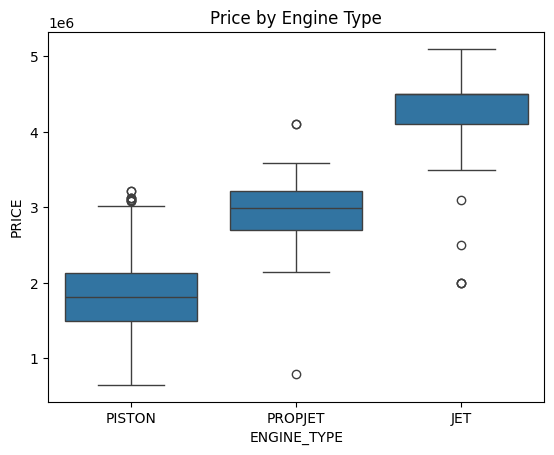

In [17]:
sns.boxplot(x="ENGINE_TYPE", y="PRICE", data=df_cast)
plt.title("Price by Engine Type")
plt.show()

Jet and propjet aircraft are significantly more expensive than piston aircraft, confirming the existence of distinct market segments.

## Aircraft Size vs Price

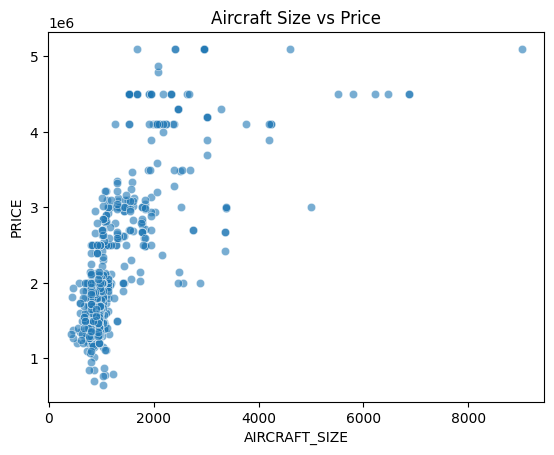

In [18]:
sns.scatterplot(x="AIRCRAFT_SIZE", y="PRICE", data=df_cast,alpha=0.6)
plt.title("Aircraft Size vs Price")
plt.show()

Aircraft size shows a strong positive relationship with price, indicating that larger aircraft tend to belong to higher price segments.

## Engine Power vs Price

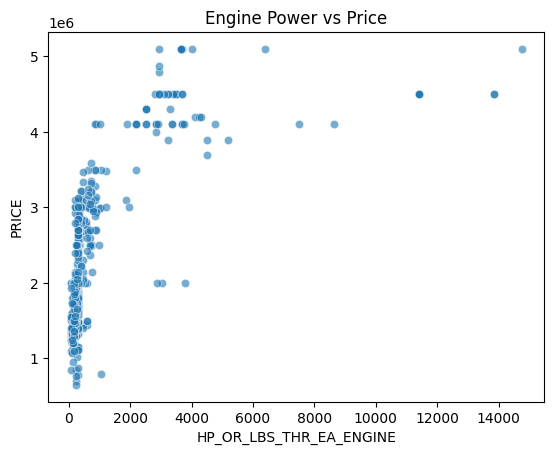

In [19]:
sns.scatterplot(x="HP_OR_LBS_THR_EA_ENGINE", y="PRICE", data=df_cast, alpha=0.6)
plt.title("Engine Power vs Price")
plt.show()

Higher engine power is associated with higher aircraft prices, particularly in high-performance aircraft categories.
Although the relationship is positive, the dispersion increases for higher values, suggesting non-linear behavior across aircraft categories.

## Power to Size Ratio vs Price

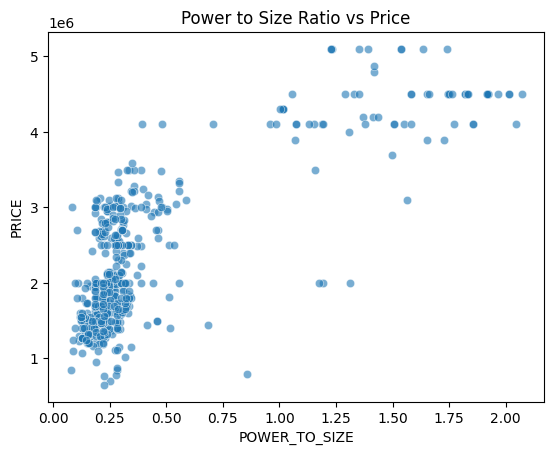

In [20]:
sns.scatterplot(x="POWER_TO_SIZE", y="PRICE", data=df_cast,alpha=0.6)
plt.title("Power to Size Ratio vs Price")
plt.show()

Aircraft with higher power-to-size ratios tend to have higher prices, suggesting that performance efficiency is a key pricing factor.
This suggests that pricing is not driven solely by size, but by how efficiently power is utilized relative to aircraft dimensions.

## Segment

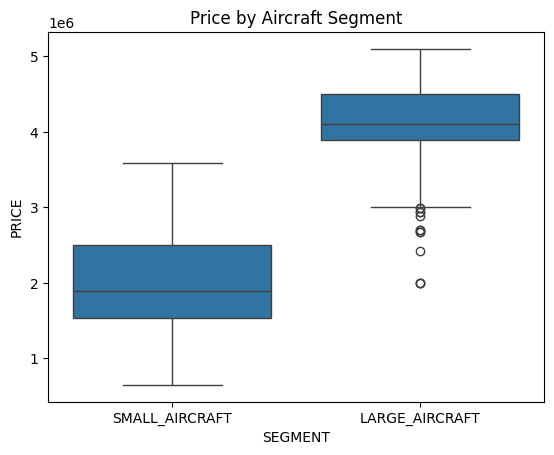

In [21]:
df_cast["SEGMENT"] = np.where(
    df_cast["FUEL_GAL/LBS"] > 600,
    "LARGE_AIRCRAFT",
    "SMALL_AIRCRAFT"
)
sns.boxplot(x="SEGMENT", y="PRICE", data=df_cast)
plt.title("Price by Aircraft Segment")
plt.show()

The dataset contains distinct aircraft segments, with large aircraft showing significantly higher prices compared to smaller aircraft.

This confirms that the dataset is not homogeneous and should be analyzed considering segmentation.

## Correlation

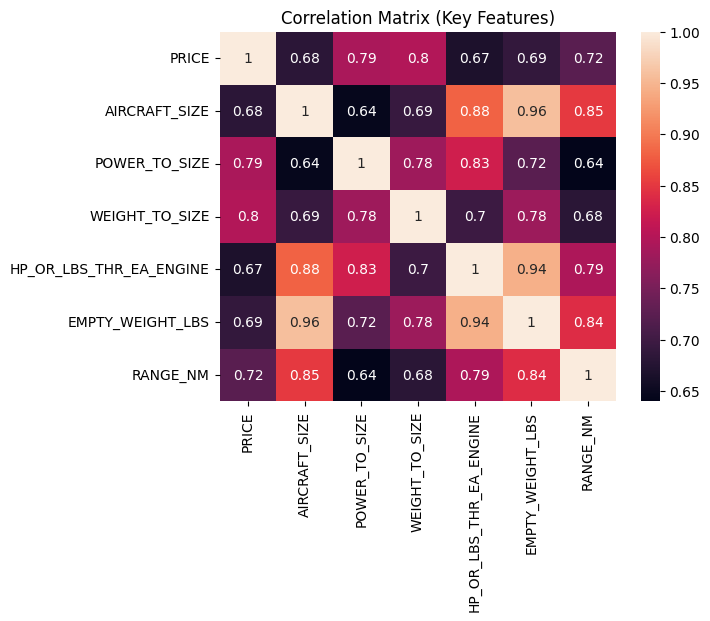

In [22]:
cols = [
    "PRICE",
    "AIRCRAFT_SIZE",
    "POWER_TO_SIZE",
    "WEIGHT_TO_SIZE",
    "HP_OR_LBS_THR_EA_ENGINE",
    "EMPTY_WEIGHT_LBS",
    "RANGE_NM"
]

corr = df_cast[cols].corr()

sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix (Key Features)")
plt.show()

Price shows strong correlations with both structural and performance-related variables.

Notably, derived features such as power-to-size ratio (0.79) and weight-to-size ratio (0.80) exhibit stronger relationships with price than raw variables like engine power (0.67) or aircraft size (0.68).

This suggests that aircraft pricing is driven more by performance efficiency than by size or power alone.

## Prediction

Modeling

A machine learning model (XGBoost Regressor) was used to predict aircraft prices based on structural and performance variables.

The model was trained using an 80/20 train-test split. XGBoost was selected due to its ability to capture non-linear relationships and interactions between variables.

The model explains approximately 88% of the variance in aircraft prices, indicating strong predictive performance.

On average, the model deviates by approximately 10–15% of typical aircraft prices, making it suitable for approximate valuation purposes.

Feature importance analysis shows that performance efficiency and aircraft size are among the most relevant predictors of price.

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import xgboost as xgb
import numpy as np


df_model = df_cast.copy()

df_model = df_model.drop(["MODEL_NAME"], axis=1)

df_model = pd.get_dummies(df_model, drop_first=True)

X = df_model.drop("PRICE", axis=1)
y = df_model["PRICE"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)


y_pred = model.predict(X_test)


metrics = {
    "R2": r2_score(y_test, y_pred),
    "MAE": mean_absolute_error(y_test, y_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred))
}

print(metrics)

{'R2': 0.8843164265025912, 'MAE': 236641.8954326923, 'RMSE': np.float64(347147.4292863658)}


## Model Performance: Real vs Predicted

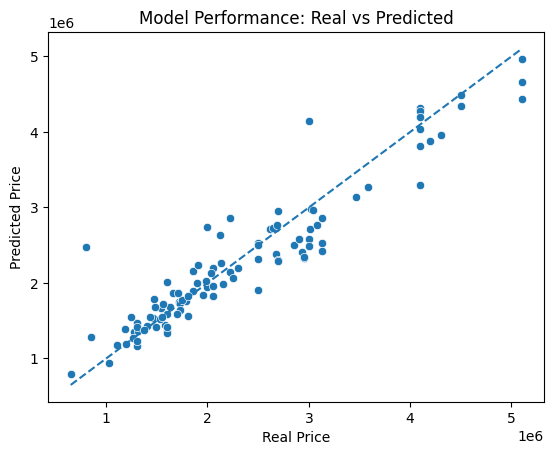

In [24]:
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle="--")

plt.xlabel("Real Price")
plt.ylabel("Predicted Price")
plt.title("Model Performance: Real vs Predicted")
plt.show()

Model Performance

The model demonstrates strong predictive capability, explaining a significant portion of price variability.

Prediction errors are within a reasonable range, suggesting that the model can be used for approximate valuation and comparison across aircraft types.

## Feature Importance

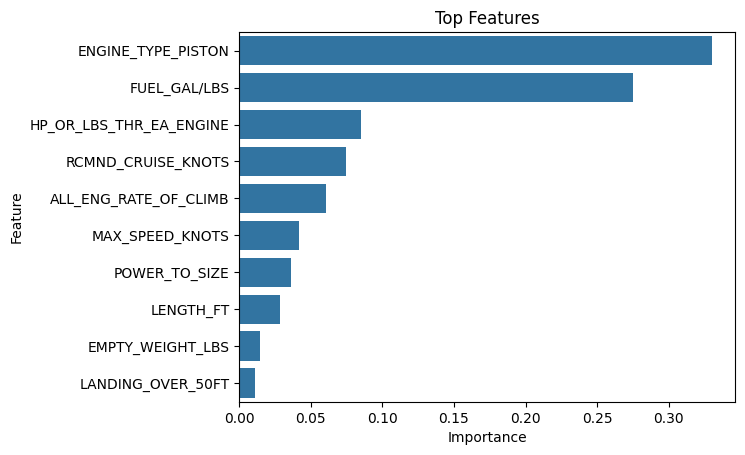

In [25]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

sns.barplot(data=importance.head(10), x="Importance", y="Feature")
plt.title("Top Features")
plt.show()

The model confirms that derived variables such as power-to-size and aircraft size are among the most influential predictors.
This reinforces the conclusion that efficiency and structural characteristics play a central role in determining aircraft price.

## Conclusion

This analysis shows that aircraft pricing is primarily driven by performance efficiency rather than size alone.

While larger aircraft tend to have higher prices, the strongest predictors are derived efficiency metrics such as power-to-size and weight-to-size ratios.

Additionally, the presence of distinct aircraft categories highlights the importance of segmentation, suggesting that pricing models should account for structural differences between aircraft types.